Cargando datos...
Iniciando preprocesamiento genérico...
Datos preparados: (500000, 81)
Entrenando modelo para Feature Importance...
Extrayendo importancias...

TOP 20 VARIABLES MÁS IMPORTANTES:
                                              feature     importance
0                                         SmartScreen  138227.587507
1                                 AVProductsInstalled   51851.124122
2                           AVProductStatesIdentifier   30067.972239
3                                        AvSigVersion   26706.401521
4                             Census_TotalPhysicalRAM   20802.464497
5                                          AppVersion   17275.864695
6                                       EngineVersion   16596.562710
7                                        Wdft_IsGamer   11527.579391
8   Census_InternalPrimaryDiagonalDisplaySizeInInches   10042.504604
9                     Census_PrimaryDiskTotalCapacity    8161.119548
10                           Census_OSInstallT

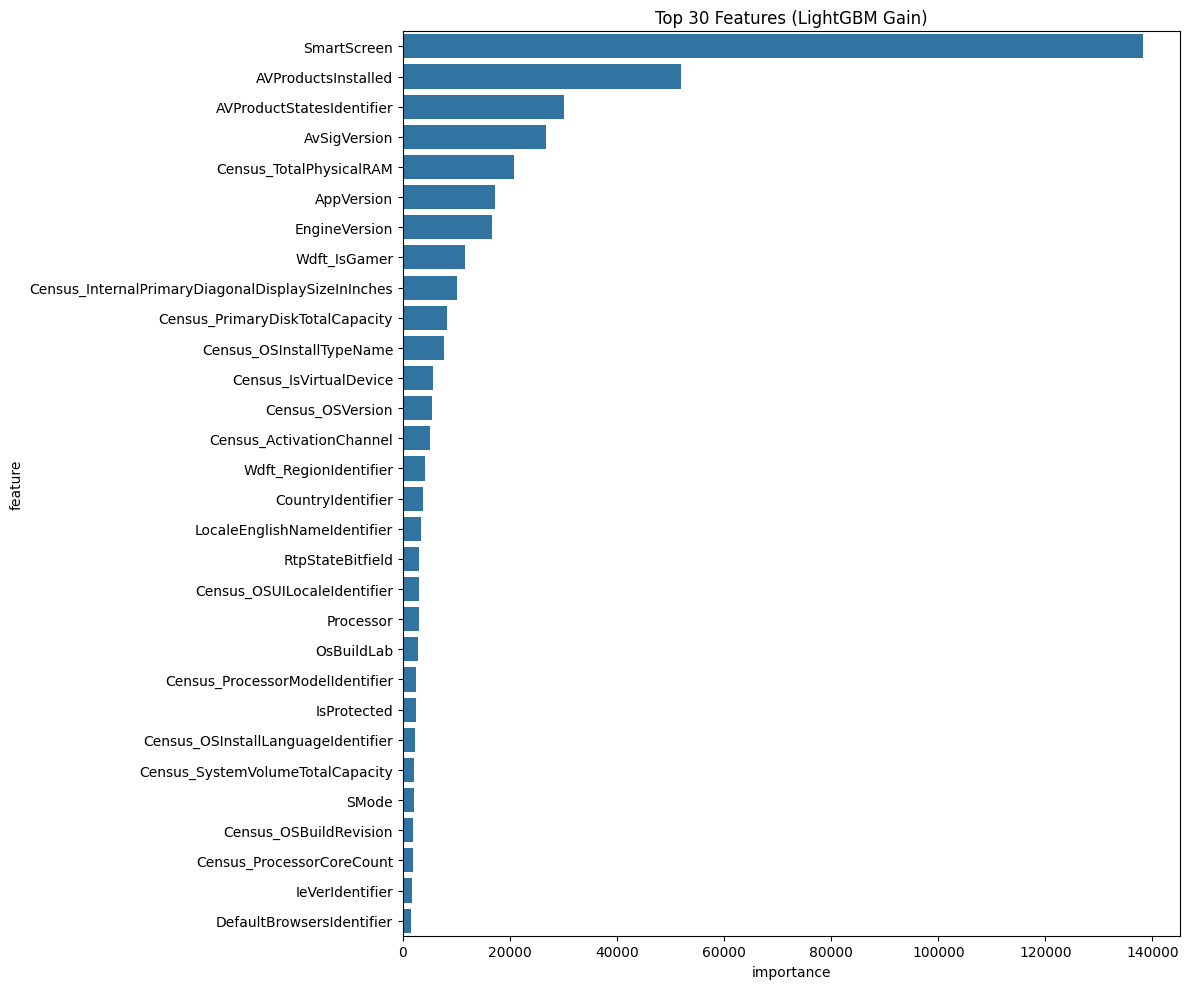

✅ Proceso terminado. Usa las top N variables del CSV generado para tu modelo final.


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb  # Mucho más rápido y eficiente en memoria que Sklearn para esto
import matplotlib.pyplot as plt
import gc # Garbage Collector para liberar memoria

# 1. CARGA DE DATOS (Optimizada)
# Especifica tipos para ahorrar memoria si es posible, o carga normal
print("Cargando datos...")
# Ajusta el path a tu archivo
ruta_archivo = "https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1"
df = pd.read_csv(ruta_archivo, low_memory=False)

# 2. PREPROCESAMIENTO 'BRUTO' (Generic & Fast)
print("Iniciando preprocesamiento genérico...")

# Identificar ID y Target
id_col = 'MachineIdentifier'
target_col = 'HasDetections'

# Eliminar ID si existe
if id_col in df.columns:
    df = df.drop(columns=[id_col])

df = df.drop(columns="Unnamed: 0")

# Separar X e y
y = df[target_col]
X = df.drop(columns=[target_col])

# Liberar memoria del dataframe original
del df
gc.collect()

# Tratamiento de Categóricas (Label Encoding rápido usando Pandas Category)
# Esto es mucho más rápido que Sklearn LabelEncoder para millones de filas
categorical_feats = [c for c in X.columns if X[c].dtype == 'object']

for col in categorical_feats:
    # Convertir a categoría y luego a códigos numéricos (-1 para nulos automáticamente o +1 para positivo)
    X[col] = X[col].astype('category')
    X[col] = X[col].cat.codes

# Tratamiento de Numéricas (Rellenar Nulos simple)
# Usamos -1 para nulos numéricos (los árboles manejan esto bien como una "categoría" aparte)
X = X.fillna(-1)

print(f"Datos preparados: {X.shape}")

# 3. ENTRENAMIENTO DE MODELO LIGERO (LightGBM)
# Usamos LGBM porque maneja nulos nativamente y es rapidísimo
print("Entrenando modelo para Feature Importance...")

# Dataset de LightGBM
dtrain = lgb.Dataset(X, label=y)

params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'metric': 'auc',
    'n_jobs': -1,       # Usar todos los núcleos
    'learning_rate': 0.1,
    'num_leaves': 31,   # Complejidad baja para ir rápido
    'max_depth': -1,
    'verbose': -1
}

# Entrenar solo 100 rondas, suficiente para ver importancia
model = lgb.train(params, dtrain, num_boost_round=100)

# 4. EXTRACCIÓN Y VISUALIZACIÓN
print("Extrayendo importancias...")

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importance(importance_type='gain') # 'gain' es más preciso que 'split'
})

# Ordenar
importance = importance.sort_values(by='importance', ascending=False).reset_index(drop=True)

# Guardar en CSV para que te lo lleves a tu código final
importance.to_csv('feature_importance_ranking.csv', index=False)

# Mostrar Top 20
print("\nTOP 20 VARIABLES MÁS IMPORTANTES:")
print(importance.head(20))

# Graficar
plt.figure(figsize=(12, 10))
sns.barplot(x="importance", y="feature", data=importance.head(30))
plt.title('Top 30 Features (LightGBM Gain)')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("✅ Proceso terminado. Usa las top N variables del CSV generado para tu modelo final.")

In [1]:
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datos
import category_encoders as ce

from scipy.stats import entropy

from sklearn import set_config

# transformers
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder, MinMaxScaler
from category_encoders import BinaryEncoder
from sklearn.base import BaseEstimator, TransformerMixin

# pipelines
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer

# model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# model evaluation
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

import sys
import os
import importlib

# Obtiene la ruta absoluta del directorio actual del script
# current_dir = os.path.dirname(os.path.abspath(__file__))  # python
current_dir = os.getcwd()                                   # jupyter notebook

# Obtiene la ruta al directorio 'src' (subiendo un nivel y entrando a src)
src_path = os.path.join(current_dir, '..', 'src')

# Lo añade al path de Python
sys.path.append(src_path)

# Ahora ya puedes importar
import utils
importlib.reload(utils);  # Forzar recarga si ya se había importado antes

from lightgbm import LGBMClassifier

def get_high_corr_cols_exclusion_pairs(df, target_col, umbral_corr):
    df_temp = df.drop(columns=[target_col])
    
    for col in df_temp.select_dtypes(include=['object', 'category']).columns:
        df_temp[col] = df_temp[col].astype('category').cat.codes
        
    corr_matrix = df_temp.corr().abs()
    cols = corr_matrix.columns
    pairs = []
    
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if corr_matrix.iloc[i, j] > umbral_corr:
                pairs.append((cols[i], cols[j]))
                
    return pairs

def get_high_corr_cols_exclusion(df, target_col, umbral_corr):
    df_temp = df.drop(columns=[target_col])
    
    for col in df_temp.select_dtypes(include=['object', 'category']).columns:
        df_temp[col] = df_temp[col].astype('category').cat.codes
        
    corr_matrix = df_temp.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    return [column for column in upper.columns if any(upper[column] > umbral_corr)]

df_inicial = pd.read_csv("https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1")
SAMPLE_SIZE = 100000 # Máximas filas para la prueba

if len(df_inicial) > SAMPLE_SIZE:
    print(f"Muestreando {SAMPLE_SIZE} filas para selección rápida de variables...")
    df_temp = df_inicial.sample(n=SAMPLE_SIZE, random_state=42).copy()
else:
    df_temp = df_inicial.copy()

# Limpieza básica inicial
df_temp = df_temp.drop(columns=['MachineIdentifier', 'Unnamed: 0'], errors='ignore')


# --- INGENIERÍA DE VARIABLES PRE-MUESTREO ---

# 1. Crear el segmento combinado (Fabricante + Núcleos)
df_temp['CPU_Architecture_Segment'] = (
    df_temp['Census_ProcessorManufacturerIdentifier'].astype(str) + 
    "_" + 
    df_temp['Census_ProcessorCoreCount'].astype(str)
).astype('category') # Forzamos a category para ahorrar memoria

# 2. Limpiar el ModelIdentifier (Agrupando raros en -1)
counts = df_temp['Census_ProcessorModelIdentifier'].value_counts()
rare_models = counts[counts < 100].index
df_temp['CPU_Model_Clean'] = df_temp['Census_ProcessorModelIdentifier'].replace(rare_models, -1).fillna(-1)

# 3. DiskSpaceDiff
df_temp['DiskSpaceDiff'] = df_temp['Census_PrimaryDiskTotalCapacity'] - df_temp['Census_SystemVolumeTotalCapacity']


# 1. ELIMINACIÓN DE CORRELACIONES ALTAS
# -------------------------------------------------------
# Buscamos columnas con correlación > 0.95
to_drop = get_high_corr_cols_exclusion(df_temp, 'HasDetections', 0.95)
print(f"Eliminando {len(to_drop)} columnas correlacionadas: {to_drop}")

X_filtered = df_temp.drop(columns=['HasDetections'] + to_drop)
y_quick = df_temp['HasDetections']

# Preparación categóricas
for col in X_filtered.select_dtypes(include=['object']).columns:
        X_filtered[col] = X_filtered[col].astype('category')

# 2. MODELO MÁS ROBUSTO
# -------------------------------------------------------
# Aumentamos estimadores y profundidad para que 'aprenda' de verdad antes de evaluar
lgbm = LGBMClassifier(
    n_estimators=1000,        # Más árboles, LGBM es rápido
    learning_rate=0.05,       # Tasa de aprendizaje conservadora
    num_leaves=31,            # Controla complejidad (equivalente a profundidad)
    objective='binary', 
    importance_type='gain',   # <--- CLAVE: Usar 'gain' es más preciso que 'split'
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

lgbm.fit(X_filtered, y_quick)

# 3. PERMUTATION IMPORTANCE (La clave de la fiabilidad)
# -------------------------------------------------------
# Esto tarda más, pero es la verdad. Mide la caída de precisión al romper la variable.
result = permutation_importance(
    lgbm, X_filtered, y_quick,
    n_repeats=5,          # Repite 5 veces para tener media y desviación
    random_state=42,
    n_jobs=-1
)

# Creamos un DF con los resultados
perm_importance = pd.DataFrame({
    'Feature': X_filtered.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

top_features = perm_importance.Feature.head(20).tolist()

df_tests = df_temp[top_features + ['HasDetections']].copy()
to_drop_again = get_high_corr_cols_exclusion(df_tests, 'HasDetections', 0.95)
df_pruned = df_tests.drop(columns=to_drop_again)

# 1. Extraer valores únicos
unique_versions = df_pruned['Census_OSVersion'].unique()
# 2. Crear un diccionario de mapeo solo para los únicos
mapping = {v: int(v.split('.')[2][:3]) for v in unique_versions if pd.notnull(v)}
# 3. Aplicar el mapeo al dataframe original (operación vectorizada)
df_pruned['Census_OSVersionEncoded'] = df_pruned['Census_OSVersion'].map(mapping)

# 1. Extraer valores únicos
unique_versions = df_pruned['AppVersion'].unique()
# 2. Crear un diccionario de mapeo solo para los únicos
mapping = {}
for v in unique_versions:
    if pd.notnull(v):
        parts = v.split('.')
        # Concatenamos el segundo bloque con los dos primeros dígitos del tercero
        code_str = parts[1] + parts[2][:3]
        mapping[v] = int(code_str)
# 3. Aplicar el mapeo al dataframe original (operación vectorizada)
df_pruned['AppVersionEncoded'] = df_pruned['AppVersion'].map(mapping)

# 1. Extraer valores únicos
unique_versions = df_pruned['AvSigVersion'].unique()
# 2. Crear un diccionario de mapeo solo para los únicos
mapping = {v: int(v.split('.')[1][:3]) for v in unique_versions if pd.notnull(v)}
# 3. Aplicar el mapeo al dataframe original (operación vectorizada)
df_pruned['AvSigVersionEncoded'] = df_pruned['AvSigVersion'].map(mapping)

df_pruned_temp = df_pruned.drop(columns=['AppVersion', 'Census_OSVersion', 'AvSigVersion'])
top_features_lgbm = top_features.copy()
top_features_lgbm

C:\Users\j\AppData\Local\Temp\ipykernel_20172\1113597270.py:78: DtypeWarning: Columns (29,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df_inicial = pd.read_csv("https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1")


Muestreando 100000 filas para selección rápida de variables...
Eliminando 5 columnas correlacionadas: ['OsVer', 'Census_OSArchitecture', 'Census_OSBuildNumber', 'Census_OSSkuName', 'Census_OSUILocaleIdentifier']


['AvSigVersion',
 'Census_OSVersion',
 'SmartScreen',
 'AVProductsInstalled',
 'AppVersion',
 'CountryIdentifier',
 'AVProductStatesIdentifier',
 'LocaleEnglishNameIdentifier',
 'DiskSpaceDiff',
 'Census_OSInstallTypeName',
 'Census_OEMModelIdentifier',
 'Census_TotalPhysicalRAM',
 'OsBuildLab',
 'Wdft_IsGamer',
 'CPU_Model_Clean',
 'CityIdentifier',
 'Census_FirmwareVersionIdentifier',
 'Census_OSEdition',
 'Wdft_RegionIdentifier',
 'Census_FirmwareManufacturerIdentifier']

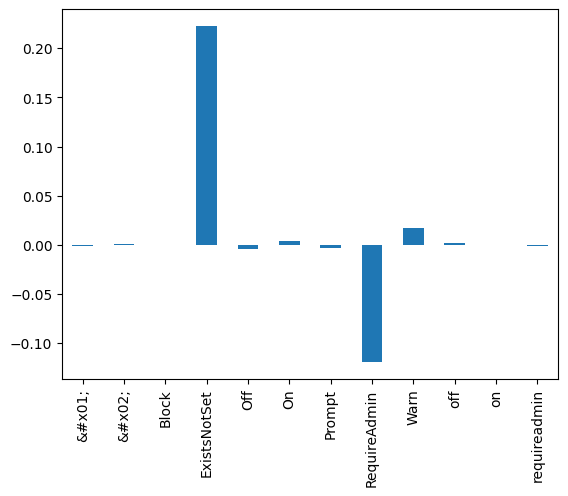

In [3]:
dummies = pd.get_dummies(df_inicial['SmartScreen'])
correlaciones = dummies.corrwith(df_inicial['HasDetections'].astype(int))
correlaciones.plot(kind='bar');

In [183]:
top_features

['AvSigVersion',
 'Census_OSVersion',
 'SmartScreen',
 'AVProductsInstalled',
 'AppVersion',
 'CountryIdentifier',
 'AVProductStatesIdentifier',
 'LocaleEnglishNameIdentifier',
 'DiskSpaceDiff',
 'Census_OSInstallTypeName',
 'Census_OEMModelIdentifier',
 'Census_TotalPhysicalRAM',
 'OsBuildLab',
 'Wdft_IsGamer',
 'CPU_Model_Clean',
 'CityIdentifier',
 'Census_FirmwareVersionIdentifier',
 'Census_OSEdition',
 'Wdft_RegionIdentifier',
 'Census_FirmwareManufacturerIdentifier']

In [190]:
df_tests = df_temp[top_features + ['HasDetections']].copy()
to_drop_again = get_high_corr_cols_exclusion(df_tests, 'HasDetections', 0.95)
df_pruned = df_tests.drop(columns=to_drop_again)

# 1. Extraer valores únicos
unique_versions = df_pruned['Census_OSVersion'].unique()
# 2. Crear un diccionario de mapeo solo para los únicos
mapping = {v: int(v.split('.')[2][:3]) for v in unique_versions if pd.notnull(v)}
# 3. Aplicar el mapeo al dataframe original (operación vectorizada)
df_pruned['Census_OSVersionEncoded'] = df_pruned['Census_OSVersion'].map(mapping)

# 1. Extraer valores únicos
unique_versions = df_pruned['AppVersion'].unique()
# 2. Crear un diccionario de mapeo solo para los únicos
mapping = {}
for v in unique_versions:
    if pd.notnull(v):
        parts = v.split('.')
        # Concatenamos el segundo bloque con los dos primeros dígitos del tercero
        code_str = parts[1] + parts[2][:3]
        mapping[v] = int(code_str)
# 3. Aplicar el mapeo al dataframe original (operación vectorizada)
df_pruned['AppVersionEncoded'] = df_pruned['AppVersion'].map(mapping)

# 1. Extraer valores únicos
unique_versions = df_pruned['AvSigVersion'].unique()
# 2. Crear un diccionario de mapeo solo para los únicos
mapping = {v: int(v.split('.')[1][:3]) for v in unique_versions if pd.notnull(v)}
# 3. Aplicar el mapeo al dataframe original (operación vectorizada)
df_pruned['AvSigVersionEncoded'] = df_pruned['AvSigVersion'].map(mapping)

df_pruned_temp = df_pruned.drop(columns=['AppVersion', 'Census_OSVersion', 'AvSigVersion'])
top_features_lgbm = top_features.copy()

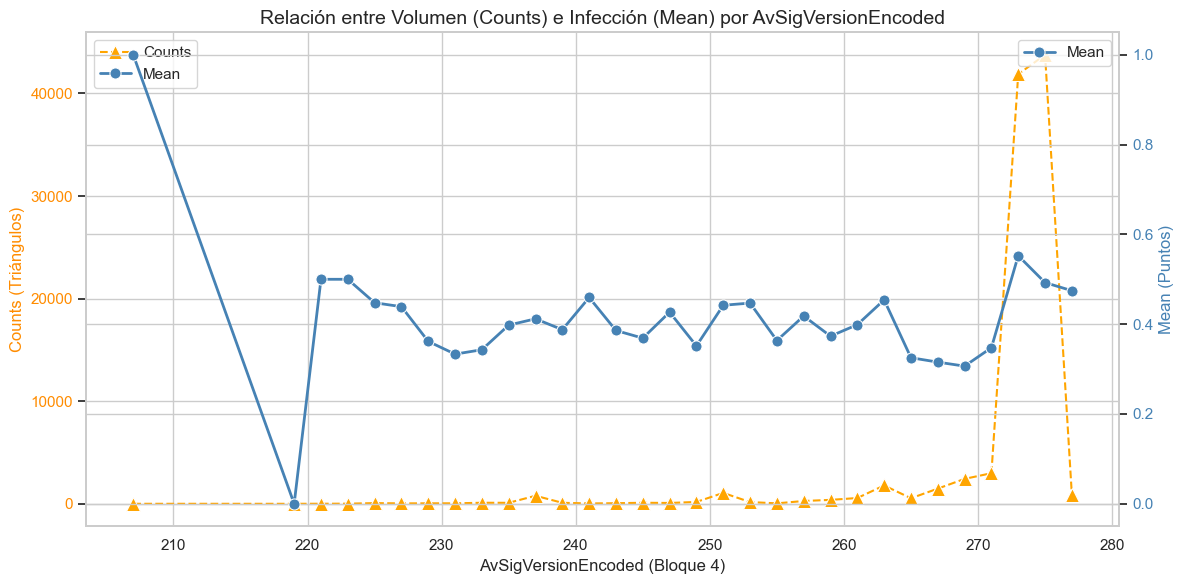

In [329]:
df_trash = df_pruned.copy()
segment=3
column_name = 'AvSigVersionEncoded'
# df_trash[column_name] = df_trash[column_name].str.split('.').str[segment].astype(int)
# stats_stable = df_trash.where((df_trash['AppVersion'] % 2 == 0) & (df_trash['AppVersion'] >= 10), np.nan).groupby('AppVersion')['HasDetections'].agg(['mean', 'count']).sort_values(by='AppVersion', ascending=False)
stats_common = df_trash.groupby(column_name)['HasDetections'].agg(['mean', 'count']).sort_values(by=column_name, ascending=False)

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_ylabel('Counts (Triángulos)', color='darkorange', fontsize=12)
sns.lineplot(data=stats_common, x=stats_common.index, y='count', 
             ax=ax1, color='orange', marker='^', markersize=10, 
             label='Counts', linestyle='--')
ax1.tick_params(axis='y', labelcolor='darkorange')

ax2 = ax1.twinx()
ax2.set_ylabel('Mean (Puntos)', color='steelblue', fontsize=12)
sns.lineplot(data=stats_common, x=stats_common.index, y='mean', 
             ax=ax2, color='steelblue', marker='o', markersize=8, 
             label='Mean', linewidth=2)
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.title('Relación entre Volumen (Counts) e Infección (Mean) por {0}'.format(column_name), fontsize=14)
ax1.set_xlabel('{0} (Bloque {1})'.format(column_name, segment+1), fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datos

from sklearn import set_config

# transformers
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder, MinMaxScaler

# pipelines
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer

# model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# model evaluation
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

import sys
import os
import importlib

# Obtiene la ruta absoluta del directorio actual del script
# current_dir = os.path.dirname(os.path.abspath(__file__))  # python
current_dir = os.getcwd()                                   # jupyter notebook

# Obtiene la ruta al directorio 'src' (subiendo un nivel y entrando a src)
src_path = os.path.join(current_dir, '..', 'src')

# Lo añade al path de Python
sys.path.append(src_path)

# Ahora ya puedes importar
import utils
importlib.reload(utils);  # Forzar recarga si ya se había importado antes

def get_high_corr_cols_exclusion_pairs(df, target_col, umbral_corr):
    df_temp = df.drop(columns=[target_col])
    
    for col in df_temp.select_dtypes(include=['object', 'category']).columns:
        df_temp[col] = df_temp[col].astype('category').cat.codes
        
    corr_matrix = df_temp.corr().abs()
    cols = corr_matrix.columns
    pairs = []
    
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if corr_matrix.iloc[i, j] > umbral_corr:
                pairs.append((cols[i], cols[j]))
                
    return pairs

def get_high_corr_cols_exclusion(df, target_col, umbral_corr):
    df_temp = df.drop(columns=[target_col])
    
    for col in df_temp.select_dtypes(include=['object', 'category']).columns:
        df_temp[col] = df_temp[col].astype('category').cat.codes
        
    corr_matrix = df_temp.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    return [column for column in upper.columns if any(upper[column] > umbral_corr)]

df_inicial = pd.read_csv("https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1")
SAMPLE_SIZE = 100000 # Máximas filas para la prueba

if len(df_inicial) > SAMPLE_SIZE:
    print(f"Muestreando {SAMPLE_SIZE} filas para selección rápida de variables...")
    df_temp = df_inicial.sample(n=SAMPLE_SIZE, random_state=42).copy()
else:
    df_temp = df_inicial.copy()

# Limpieza básica inicial
df_temp = df_temp.drop(columns=['MachineIdentifier', 'Unnamed: 0'], errors='ignore').fillna(-1)


# --- INGENIERÍA DE VARIABLES PRE-MUESTREO ---

# 1. Crear el segmento combinado (Fabricante + Núcleos)
df_temp['CPU_Architecture_Segment'] = (
    df_temp['Census_ProcessorManufacturerIdentifier'].astype(str) + 
    "_" + 
    df_temp['Census_ProcessorCoreCount'].astype(str)
).astype('category') # Forzamos a category para ahorrar memoria

# 2. Limpiar el ModelIdentifier (Agrupando raros en -1)
counts = df_temp['Census_ProcessorModelIdentifier'].value_counts()
rare_models = counts[counts < 100].index
df_temp['CPU_Model_Clean'] = df_temp['Census_ProcessorModelIdentifier'].replace(rare_models, -1).fillna(-1)

# 3. DiskSpaceDiff
df_temp['DiskSpaceDiff'] = df_temp['Census_PrimaryDiskTotalCapacity'] - df_temp['Census_SystemVolumeTotalCapacity']


# 1. ELIMINACIÓN DE CORRELACIONES ALTAS
# -------------------------------------------------------
# Buscamos columnas con correlación > 0.95
to_drop = get_high_corr_cols_exclusion(df_temp, 'HasDetections', 0.95)
print(f"Eliminando {len(to_drop)} columnas correlacionadas: {to_drop}")

X_filtered = df_temp.drop(columns=['HasDetections'] + to_drop)
y_quick = df_temp['HasDetections']

# Preparación categóricas
for col in X_filtered.select_dtypes(include=['object', 'category']).columns:
        X_filtered[col] = X_filtered[col].astype('category').cat.codes

# 2. MODELO MÁS ROBUSTO
# -------------------------------------------------------
# Aumentamos estimadores y profundidad para que 'aprenda' de verdad antes de evaluar
rf_robust = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=20,  # Evita overfitting a ruido
    max_depth=None,       # Deja crecer el árbol (controlado por min_samples_leaf)
    oob_score=True,       # Validación interna gratuita
    n_jobs=-1,
    random_state=42
)

rf_robust.fit(X_filtered, y_quick)

# 3. PERMUTATION IMPORTANCE (La clave de la fiabilidad)
# -------------------------------------------------------
# Esto tarda más, pero es la verdad. Mide la caída de precisión al romper la variable.
result = permutation_importance(
    rf_robust, X_filtered, y_quick,
    n_repeats=5,          # Repite 5 veces para tener media y desviación
    random_state=42,
    n_jobs=-1
)

# Creamos un DF con los resultados
perm_importance = pd.DataFrame({
    'Feature': X_filtered.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

top_features = perm_importance.Feature.head(20).tolist()

df_tests = df_temp[top_features + ['HasDetections']].copy()
to_drop_again = get_high_corr_cols_exclusion(df_tests, 'HasDetections', 0.95)
df_pruned = df_tests.drop(columns=to_drop_again)

# 1. Extraer valores únicos
unique_versions = df_pruned['Census_OSVersion'].unique()
# 2. Crear un diccionario de mapeo solo para los únicos
mapping = {v: int(v.split('.')[2][:3]) for v in unique_versions if pd.notnull(v)}
# 3. Aplicar el mapeo al dataframe original (operación vectorizada)
df_pruned['Census_OSVersionEncoded'] = df_pruned['Census_OSVersion'].map(mapping)

# 1. Extraer valores únicos
unique_versions = df_pruned['AppVersion'].unique()
# 2. Crear un diccionario de mapeo solo para los únicos
mapping = {}
for v in unique_versions:
    if pd.notnull(v):
        parts = v.split('.')
        # Concatenamos el segundo bloque con los dos primeros dígitos del tercero
        code_str = parts[1] + parts[2][:3]
        mapping[v] = int(code_str)
# 3. Aplicar el mapeo al dataframe original (operación vectorizada)
df_pruned['AppVersionEncoded'] = df_pruned['AppVersion'].map(mapping)

# 1. Extraer valores únicos
unique_versions = df_pruned['AvSigVersion'].unique()
# 2. Crear un diccionario de mapeo solo para los únicos
mapping = {v: int(v.split('.')[1][:3]) for v in unique_versions if pd.notnull(v)}
# 3. Aplicar el mapeo al dataframe original (operación vectorizada)
df_pruned['AvSigVersionEncoded'] = df_pruned['AvSigVersion'].map(mapping)

df_pruned_temp = df_pruned.drop(columns=['AppVersion', 'Census_OSVersion', 'AvSigVersion'])

In [181]:
top_features_rf = top_features.copy()

In [184]:
top_features_rf

['SmartScreen',
 'AVProductsInstalled',
 'AVProductStatesIdentifier',
 'Census_OSInstallTypeName',
 'Census_ProcessorModelIdentifier',
 'Wdft_IsGamer',
 'Census_OSVersionEncoded',
 'AppVersionEncoded',
 'AvSigVersionEncoded',
 'Wdft_RegionIdentifier']

In [7]:
df_pruned_temp.columns

Index(['SmartScreen', 'AVProductsInstalled', 'AVProductStatesIdentifier',
       'Census_OSInstallTypeName', 'Census_ProcessorModelIdentifier',
       'Census_SystemVolumeTotalCapacity', 'Wdft_IsGamer',
       'Census_PrimaryDiskTotalCapacity', 'CityIdentifier',
       'Census_OEMModelIdentifier', 'Census_OSBuildRevision',
       'LocaleEnglishNameIdentifier', 'Census_FirmwareVersionIdentifier',
       'Census_TotalPhysicalRAM', 'GeoNameIdentifier', 'Wdft_RegionIdentifier',
       'HasDetections', 'Census_OSVersionEncoded', 'AppVersionEncoded',
       'AvSigVersionEncoded'],
      dtype='object')

In [8]:
for i in df_pruned_temp.columns:
    prctj = df_pruned_temp[i].isnull().mean() * 100
    quantity = df_pruned_temp[i].isnull().sum()
    print(f'{prctj:3.3f}% \t {quantity} \tde nulos en {i}')

35.719% 	 178596 	de nulos en SmartScreen
0.388% 	 1938 	de nulos en AVProductsInstalled
0.388% 	 1938 	de nulos en AVProductStatesIdentifier
0.000% 	 0 	de nulos en Census_OSInstallTypeName
0.470% 	 2349 	de nulos en Census_ProcessorModelIdentifier
0.595% 	 2976 	de nulos en Census_SystemVolumeTotalCapacity
3.390% 	 16950 	de nulos en Wdft_IsGamer
0.595% 	 2976 	de nulos en Census_PrimaryDiskTotalCapacity
3.648% 	 18240 	de nulos en CityIdentifier
1.153% 	 5764 	de nulos en Census_OEMModelIdentifier
0.000% 	 0 	de nulos en Census_OSBuildRevision
0.000% 	 0 	de nulos en LocaleEnglishNameIdentifier
1.812% 	 9061 	de nulos en Census_FirmwareVersionIdentifier
0.911% 	 4556 	de nulos en Census_TotalPhysicalRAM
0.003% 	 16 	de nulos en GeoNameIdentifier
3.390% 	 16950 	de nulos en Wdft_RegionIdentifier
0.000% 	 0 	de nulos en HasDetections
0.000% 	 0 	de nulos en Census_OSVersionEncoded
0.000% 	 0 	de nulos en AppVersionEncoded
0.000% 	 0 	de nulos en AvSigVersionEncoded


In [173]:
print(df_pruned.groupby('GeoNameIdentifier')['HasDetections'].agg(['mean', 'count']).sort_index(ascending=False))
print(df_pruned.groupby('CityIdentifier')['HasDetections'].agg(['mean', 'count']).sort_index(ascending=False))
print(df_pruned.groupby('Wdft_RegionIdentifier')['HasDetections'].agg(['mean', 'count']).sort_index(ascending=False))
print(df_inicial.groupby('CountryIdentifier')['HasDetections'].agg(['mean', 'count']).sort_values(by='count', ascending=False))

# Agrupación multivariante (Geo, Ciudad, Región)
cols_geo = ['GeoNameIdentifier', 'CityIdentifier', 'Wdft_RegionIdentifier', 'CountryIdentifier']
stats = df_inicial.groupby(cols_geo)[target].agg(['mean', 'count'])
stats_filtered = stats[stats['count'] > 1000].sort_values(by='mean', ascending=False)
print(stats_filtered)

                       mean  count
GeoNameIdentifier                 
296.0              0.428571      7
295.0              0.502347    426
294.0              0.507463    201
293.0              0.578947     95
292.0              0.000000      1
...                     ...    ...
5.0                0.384615     26
4.0                0.875000      8
3.0                0.461883    223
2.0                0.554745    137
1.0                0.666667     54

[268 rows x 2 columns]
                    mean  count
CityIdentifier                 
167958.0        1.000000      1
167954.0        0.000000      4
167953.0        0.500000      4
167946.0        0.000000      2
167944.0        0.500000      2
...                  ...    ...
16.0            0.000000      1
12.0            0.666667      3
11.0            0.000000      1
8.0             0.000000      1
7.0             1.000000      1

[37157 rows x 2 columns]
                           mean   count
Wdft_RegionIdentifier                  

In [100]:
stats = df_inicial.groupby(['Census_ProcessorManufacturerIdentifier', 'Census_ProcessorCoreCount', 'Census_ProcessorModelIdentifier'])[target].agg(['mean', 'count'])
stats_filtered = stats[stats['count'] > 1000].sort_values(by='mean', ascending=False)
stats_filtered.head(20)
# stats_filtered.tail(10)

mean  \
Census_ProcessorManufacturerIdentifier Census_ProcessorCoreCount Census_ProcessorModelIdentifier             
5.0                                    8.0                       3082.0                           0.607013   
                                       12.0                      3117.0                           0.604505   
                                       8.0                       3038.0                           0.603717   
                                       4.0                       2701.0                           0.597656   
                                       8.0                       3041.0                           0.591937   
                                       6.0                       2749.0                           0.585099   
                                       8.0                       2891.0                           0.584007   
                                       4.0                       2604.0                           0.579887   
                                                                 3026.0                           0.579608   
                                                                 2349.0                           0.578431   
                                       8.0                       2962.0                           0.573015   
                                       4.0                       2998.0                           0.571898   
                                       12.0                      3125.0                           0.565004   
                                       8.0                       3035.0                           0.564220   
                                       4.0                       3063.0                           0.563458   
                                                                 2706.0                           0.561850   
                                       8.0                       3079.0                           0.561670   
                                       4.0                       2908.0                           0.561036   
                                                                 2660.0                           0.559600   
                                       8.0                       2930.0                           0.554724   

                                                                                                  count  
Census_ProcessorManufacturerIdentifier Census_ProcessorCoreCount Census_ProcessorModelIdentifier         
5.0                                    8.0                       3082.0                            4962  
                                       12.0                      3117.0                            1110  
                                       8.0                       3038.0                            3659  
                                       4.0                       2701.0                            2304  
                                       8.0                       3041.0                            1017  
                                       6.0                       2749.0                            1369  
                                       8.0                       2891.0                            1113  
                                       4.0                       2604.0                            2128  
                                                                 3026.0                            4384  
                                                                 2349.0                            1020  
                                       8.0                       2962.0                            1171  
                                       4.0                       2998.0                            3046  
                                       12.0                      3125.0                            1223  
                                       8.0                       3035.0                    

In [109]:
from sklearn.feature_selection import mutual_info_classif

# Seleccionamos las columnas a comparar
cols_to_test = [
    'Census_ProcessorModelIdentifier',        # Original (Ruidosa)
    'Census_ProcessorModelIdentifier_Clean',  # Tu versión con -1
    'Census_ProcessorCoreCount',              # Solo cores
    'CPU_Architecture_Segment'                # Tu nueva combinada (necesita cat.codes)
]

# Preparamos los datos (MI requiere valores numéricos, usamos cat.codes solo para el test)
X_test = df_test[cols_to_test].copy()
for col in X_test.select_dtypes(include=['object']).columns:
    X_test[col] = X_test[col].astype('category').cat.codes

# Calculamos MI
importances = mutual_info_classif(X_test.fillna(-1), df_test[target])

# Visualizamos
mi_results = pd.Series(importances, index=cols_to_test).sort_values(ascending=False)
print(mi_results)

CPU_Architecture_Segment                 0.021922
Census_ProcessorCoreCount                0.020502
Census_ProcessorModelIdentifier          0.009454
Census_ProcessorModelIdentifier_Clean    0.007209
dtype: float64


Resumen Ejecutivo del Target: HasDetections
   count  nunique     mean
500000.0      2.0 0.499906

Distribución de Clases:
               Conteo  Frecuencia (%)
HasDetections                        
0              250047         50.0094
1              249953         49.9906


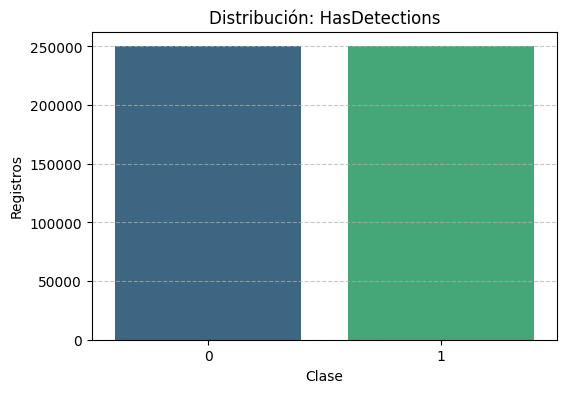

In [52]:
# 1. Estadísticos descriptivos básicos
stats = df_inicial[target].agg(['count', 'nunique', 'mean']).to_frame().T
counts = df_inicial[target].value_counts(dropna=False)
dist = df_inicial[target].value_counts(normalize=True, dropna=False).mul(100)

# 2. Consolidación de reporte
report = pd.DataFrame({
    'Conteo': counts,
    'Frecuencia (%)': dist.round(4)
})

print(f"Resumen Ejecutivo del Target: {target}")
print(stats.to_string(index=False))
print("\nDistribución de Clases:")
print(report)

# 3. Visualización mínima
plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='viridis', legend=False)
plt.title(f"Distribución: {target}")
plt.ylabel("Registros")
plt.xlabel("Clase")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datos
import category_encoders as ce

from scipy.stats import entropy

from sklearn import set_config

# transformers
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder, MinMaxScaler
from category_encoders import BinaryEncoder
from sklearn.base import BaseEstimator, TransformerMixin

# pipelines
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer

# model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# model evaluation
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

import sys
import os
import importlib

# Obtiene la ruta absoluta del directorio actual del script
# current_dir = os.path.dirname(os.path.abspath(__file__))  # python
current_dir = os.getcwd()                                   # jupyter notebook

# Obtiene la ruta al directorio 'src' (subiendo un nivel y entrando a src)
src_path = os.path.join(current_dir, '..', 'src')

# Lo añade al path de Python
sys.path.append(src_path)

# Ahora ya puedes importar
import utils
importlib.reload(utils);  # Forzar recarga si ya se había importado antes

from lightgbm import LGBMClassifier

def get_high_corr_cols_exclusion_pairs(df, target_col, umbral_corr):
    df_temp = df.drop(columns=[target_col])
    
    for col in df_temp.select_dtypes(include=['object', 'category']).columns:
        df_temp[col] = df_temp[col].astype('category').cat.codes
        
    corr_matrix = df_temp.corr().abs()
    cols = corr_matrix.columns
    pairs = []
    
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if corr_matrix.iloc[i, j] > umbral_corr:
                pairs.append((cols[i], cols[j]))
                
    return pairs

def get_high_corr_cols_exclusion(df, target_col, umbral_corr):
    df_temp = df.drop(columns=[target_col])
    
    for col in df_temp.select_dtypes(include=['object', 'category']).columns:
        df_temp[col] = df_temp[col].astype('category').cat.codes
        
    corr_matrix = df_temp.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    return [column for column in upper.columns if any(upper[column] > umbral_corr)]

class ScaledKNNImputer(BaseEstimator, TransformerMixin):
    def __init__(self, scaler=None, imputer=None):
        self.scaler = scaler if scaler else StandardScaler()
        self.imputer = imputer if imputer else KNNImputer(n_neighbors=5)
        
    def fit(self, X, y=None):
        # 1. Ajustamos el escalador con los datos disponibles
        self.scaler.fit(X)
        # 2. Transformamos para que el KNN aprenda sobre datos escalados
        X_scaled = self.scaler.transform(X)
        # 3. Ajustamos el KNN
        self.imputer.fit(X_scaled)
        return self

    def transform(self, X):
        # 1. Escalar
        X_scaled = self.scaler.transform(X)
        # 2. Imputar (devuelve datos escalados sin nulos)
        X_imputed_scaled = self.imputer.transform(X_scaled)
        # 3. Desescalar (volvemos a las unidades originales)
        X_imputed_original = self.scaler.inverse_transform(X_imputed_scaled)
        
        if isinstance(X, pd.DataFrame):
            return pd.DataFrame(
                X_imputed_original, 
                columns=X.columns, 
                index=X.index
            )
        return X_imputed_original

knn_wrapper = ScaledKNNImputer(
    scaler=StandardScaler(), # MinMaxScaler()/RobustScaler() si quieres otro tipo de escalado
    imputer=KNNImputer(n_neighbors=5) # Lo dejamos aquí para poder poner los neighbors que queramos
)

class CategoricalKNNImputer(BaseEstimator, TransformerMixin):
    """
    Pipeline interno: 
    Texto -> Ordinal (Int) -> Scaler (Float) -> KNN -> Inverse Scaler -> Round -> Inverse Ordinal -> Texto
    """
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.encoder = None
        self.scaler = None
        self.imputer = None

    def fit(self, X, y=None):

        self.encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
        self.encoder.fit(X)
        X_encoded = self.encoder.transform(X)
        
        # 2. Scaler
        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X_encoded)
        
        # 3. KNN
        self.imputer = KNNImputer(n_neighbors=self.n_neighbors)
        self.imputer.fit(X_scaled)
        
        return self

    def transform(self, X):
        # 1. Encode
        X_encoded = self.encoder.transform(X)
        
        # 2. Scale
        X_scaled = self.scaler.transform(X_encoded)
        
        # 3. Impute
        X_imputed_scaled = self.imputer.transform(X_scaled)
        
        # 4. Inverse Scale
        X_imputed_numeric = self.scaler.inverse_transform(X_imputed_scaled)
        
        # 5. Round (importante: KNN devuelve floats, necesitamos índices enteros para volver a texto)
        X_imputed_int = np.round(X_imputed_numeric)
        
        # 6. Inverse Encode (volvemos a los strings originales)
        X_final = self.encoder.inverse_transform(X_imputed_int)
        
        if isinstance(X, pd.DataFrame):
            return pd.DataFrame(X_final, columns=X.columns, index=X.index)
        return X_final

knn_cat_wrapper = CategoricalKNNImputer(n_neighbors=5)

class DominantCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8, other_label='Other', n_fixed=None):
        """
        Agrupa categorías hasta alcanzar el 'threshold' de cobertura acumulada.
        
        Args:
            threshold (float): Cobertura acumulada deseada (ej: 0.8 para el 80%).
            other_label (str/int): Etiqueta para las categorías minoritarias.
            n_fixed (int, opcional): Si se define, ignora el threshold y se queda 
                                     fijo con las top N categorías.
        """
        self.threshold = threshold
        self.other_label = other_label
        self.n_fixed = n_fixed
        self.top_categories_ = {} # Aquí guardaremos la "memoria" de cada columna

    def fit(self, X, y=None):
        # Validamos si es DataFrame o array
        if isinstance(X, pd.DataFrame):
            X_data = X
        else:
            X_data = pd.DataFrame(X)
            
        for col in X_data.columns:
            # Calculamos frecuencias relativas
            freqs = X_data[col].value_counts(normalize=True).sort_values(ascending=False)
            
            if self.n_fixed:
                # Estrategia: N Fijo
                top_cats = freqs.head(self.n_fixed).index.tolist()
            else:
                # Estrategia: Cobertura Acumulada (Threshold)
                cumsum = freqs.cumsum()
                # Buscamos el índice donde superamos el corte (ej. 0.8)
                cutoff_idx = cumsum[cumsum >= self.threshold].index
                
                if len(cutoff_idx) > 0:
                    # Tomamos hasta la primera categoría que cruza el umbral
                    # (o todas si ninguna lo cruza por sí sola, lógica de corte)
                    idx_position = freqs.index.get_loc(cutoff_idx[0])
                    top_cats = freqs.iloc[:idx_position + 1].index.tolist()
                else:
                    top_cats = freqs.index.tolist() # Casuística rara, nos quedamos con todo
            
            self.top_categories_[col] = top_cats
            
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X_out = X.copy()
        else:
            X_out = pd.DataFrame(X).copy()
            
        for col, valid_cats in self.top_categories_.items():
            if col in X_out.columns:
                # 1. Crear máscara de lo que NO está en el top
                # IMPORTANTE: No tocar los Nulos (isna)
                mask_others = (~X_out[col].isin(valid_cats)) & (X_out[col].notna())
                
                # 2. Reemplazar
                if mask_others.any():
                    # Convertimos a object/str si era categórica para evitar error de categorías nuevas
                    if isinstance(X_out[col].dtype, pd.CategoricalDtype):
                         X_out[col] = X_out[col].astype(object)
                    
                    X_out.loc[mask_others, col] = self.other_label
                    
        return X_out

def imputar_por_similitud(df, target_col, numeric_cols, cat_bool_cols, umbral_dominancia=0.75, margen_global=0.05, usar_percentiles=False, estrategia='moda'):
    """
        Imputa valores nulos en una columna objetivo basándose en la similitud con otros registros (vecinos).

        Esta función busca filas similares a aquellas que tienen datos faltantes en `target_col`.
        La similitud se define mediante coincidencias exactas en variables categóricas/booleanas
        y proximidad dentro de un margen en variables numéricas.

        Lógica de búsqueda de vecinos:
        1. Filtro estricto: Debe coincidir el valor en todas las columnas de `cat_bool_cols`.
        2. Filtro numérico: El valor debe estar dentro de un rango (margen) definido para `numeric_cols`.
        - Si `usar_percentiles=False`: Rango = valor ± (valor * margen).
        - Si `usar_percentiles=True`: Rango = percentiles correspondientes al (rank_actual ± margen).

        Args:
            df (pd.DataFrame): DataFrame original conteniendo los datos.
            target_col (str): Nombre de la columna que contiene los valores nulos a imputar.
            numeric_cols (list o dict):
                - Si es lista: Columnas numéricas para comparar similitud usando `margen_global`.
                - Si es dict: Claves son columnas y valores son el margen específico para esa columna (ej. {'edad': 0.1}).
            cat_bool_cols (list): Lista de columnas categóricas o booleanas para coincidencia exacta (Hard matching).
            umbral_dominancia (float, opcional): Solo para estrategia 'moda'. Porcentaje mínimo de coincidencia
                entre vecinos para aceptar la imputación (defecto 0.75).
            margen_global (float, opcional): Tolerancia por defecto para la comparación numérica (defecto 0.05 o 5%).
            usar_percentiles (bool, opcional): Define cómo se calcula el margen numérico.
                False usa distancia relativa al valor; True usa distancia en la distribución (quantiles).
            estrategia (str, opcional): Método de agregación de los vecinos encontrados.
                - 'moda': Valor más frecuente (requiere cumplir `umbral_dominancia`).
                - 'mediana': Mediana de los vecinos (soporta números y fechas).
                - 'media': Promedio aritmético (solo números).

        Returns:
            pd.DataFrame: Una copia del DataFrame original con los valores imputados donde fue posible.
    """

    df_out = df.copy()

    if df_out[target_col].isnull().sum() == 0:
        return df_out

    filas_nulas = df_out[df_out[target_col].isnull()]
    #print(f"Procesando {len(filas_nulas)} nulos en '{target_col}' | Estrategia: {estrategia} | Percentiles: {usar_percentiles}...")

    imputaciones = 0

    # Pre-procesamiento config numérica
    if isinstance(numeric_cols, list):
        numeric_config = {col: margen_global for col in numeric_cols}
    else:
        numeric_config = numeric_cols

    for idx, row in filas_nulas.iterrows():
        mask = pd.Series([True] * len(df), index=df.index)

        # 1. Filtros
        for col in cat_bool_cols:
            valor = row[col]
            if not pd.isna(valor):
                mask &= (df[col] == valor)

        for col, margen_especifico in numeric_config.items():
            valor = row[col]
            if not pd.isna(valor):
                if usar_percentiles:
                    # Lógica Percentil
                    rank_actual = (df[col] < valor).mean()
                    q_min = max(0, rank_actual - margen_especifico)
                    q_max = min(1, rank_actual + margen_especifico)
                    try:
                        lim_inf = df[col].quantile(q_min)
                        lim_sup = df[col].quantile(q_max)
                        mask &= (df[col].between(lim_inf, lim_sup))
                    except: pass
                else:
                    # Lógica Rango Fijo
                    try:
                        lim_inf = valor * (1 - margen_especifico)
                        lim_sup = valor * (1 + margen_especifico)
                        if valor < 0: lim_inf, lim_sup = lim_sup, lim_inf
                        mask &= (df[col].between(lim_inf, lim_sup))
                    except: pass

        mask &= (df.index != idx)
        vecinos = df.loc[mask, target_col]

        vecinos = vecinos.dropna()

        if vecinos.empty:
            continue

        # 2. DECISIÓN SEGÚN ESTRATEGIA
        valor_imputado = None

        if estrategia == 'moda':
            # Lógica original: Requiere consenso
            conteo = vecinos.value_counts(normalize=True)
            if not conteo.empty:
                if conteo.iloc[0] >= umbral_dominancia:
                    valor_imputado = conteo.index[0]

        elif estrategia == 'mediana':
            # Lógica numérica/fechas: Valor central
            # Para fechas, convertimos a numérico, calculamos mediana y reconvertimos
            if pd.api.types.is_datetime64_any_dtype(vecinos):
                mediana_num = vecinos.astype(np.int64).median()
                valor_imputado = pd.to_datetime(mediana_num)
            else:
                valor_imputado = vecinos.median()

        elif estrategia == 'media':
             if pd.api.types.is_numeric_dtype(vecinos):
                valor_imputado = vecinos.mean()

        # 3. Asignación
        if valor_imputado is not None:
            df_out.at[idx, target_col] = valor_imputado
            imputaciones += 1

    #print(f"Terminado: Se imputaron {imputaciones} de {len(filas_nulas)} ({round(imputaciones/len(filas_nulas)*100, 2)}%).")
    return df_out

def binary_encoding(df, col_name, drop_original=True):

    temp_col = df[col_name].astype('category').cat.codes
    num_unique = df[col_name].nunique()
    num_bits = int(np.ceil(np.log2(num_unique))) if num_unique > 1 else 1
    def int_to_bits(n):
        binary_str = format(n, f'0{num_bits}b')
        return [int(d) for d in binary_str]
    bit_cols = []
    for i in range(num_bits):
        bit_col_vals = (temp_col.values >> i) & 1
        bit_cols.append(bit_col_vals)
    bit_cols = bit_cols[::-1]
    new_col_names = [f"{col_name}_bin_{i}" for i in range(num_bits)]
    binary_df = pd.DataFrame(np.column_stack(bit_cols), columns=new_col_names, index=df.index)
    df_out = pd.concat([df, binary_df], axis=1)
    if drop_original:
        df_out = df_out.drop(columns=[col_name])
    return df_out

MyCustomImputer = FunctionTransformer(
    func = imputar_por_similitud,
    kw_args={
        "target_col": None,
        "numeric_cols": {
            None : None,
            None : None 
        },
        "cat_bool_cols": None,
        "estrategia": None
    }
)

def preprocess_columns(df):
    unique_versions = df['Census_OSVersion'].unique()
    mapping = {v: int(v.split('.')[2][:3]) for v in unique_versions if pd.notnull(v)}
    df['Census_OSVersion'] = df['Census_OSVersion'].map(mapping)

    unique_versions = df['AppVersion'].unique()
    mapping = {}
    for v in unique_versions:
        if pd.notnull(v):
            parts = v.split('.')
            code_str = parts[1] + parts[2][:3]
            mapping[v] = int(code_str)
    df['AppVersion'] = df['AppVersion'].map(mapping)

    unique_versions = df['AvSigVersion'].unique()
    mapping = {}
    for v in unique_versions:
        if pd.notnull(v):
            parts = v.split('.')
            code_str = parts[1] + parts[2][:3]
            mapping[v] = int(code_str)
    df['AvSigVersion'] = df['AvSigVersion'].map(mapping)

    df['SmartScreen'] = df['SmartScreen'].str.lower().replace(['&#x02;', '&#x01;'], np.nan)
    agrupacion_smartscreen = {
        'off': 'off',
        'existsnotset': 'existsnotset',
        'warn': 'warn',
        'prompt': 'prompt',
        'block': 'block',
        'requireadmin': 'requireadmin',
        'on': 'requireadmin'
    }
    df['SmartScreen'] = df['SmartScreen'].map(agrupacion_smartscreen)

    df['DiskSpaceDiff'] = df['Census_PrimaryDiskTotalCapacity'] - df['Census_SystemVolumeTotalCapacity']
    df['DiskSpaceDiff'] = df['DiskSpaceDiff'].where(df['DiskSpaceDiff'] >= 0, np.nan)

    df['Census_TotalPhysicalRAM'] = df['Census_TotalPhysicalRAM'].map(lambda x: np.log2(x) - 10 if x > 0 else np.nan)

    edition_map = {
        # Familia CORE (Hogar/Estándar)
        'Core': 'Core',
        'CoreSingleLanguage': 'Core',
        'CoreCountrySpecific': 'Core',
        'CoreN': 'Core',
        'Cloud': 'Core',
        # Familia PROFESSIONAL
        'Professional': 'Professional',
        'ProfessionalN': 'Professional',
        'ProfessionalEducation': 'Professional',
        'ProfessionalEducationN': 'Professional',
        'ProfessionalWorkstation': 'Professional',
        'ProfessionalWorkstationN': 'Professional',
        # Familia EDUCATION
        'Education': 'Education',
        'EducationN': 'Education',
        # Familia ENTERPRISE (Empresa/LTSB)
        'Enterprise': 'Enterprise',
        'EnterpriseN': 'Enterprise',
        'EnterpriseS': 'Enterprise',
        'EnterpriseSN': 'Enterprise',
        # Familia SERVER
        'ServerStandard': 'Server',
        'ServerStandardEval': 'Server',
        'ServerDatacenterEval': 'Server',
        'ServerSolution': 'Server'
    }
    # df['Census_OSEdition'] = df['Census_OSEdition'].map(edition_map)

    mapeo_uac = {0: 0, 1: 1, 0.0: 0, 1.0: 1}
    df['UacLuaenable'] = df['UacLuaenable'].map(mapeo_uac)

    df['Census_InternalPrimaryDisplayResolutionHorizontal'] = df['Census_InternalPrimaryDisplayResolutionHorizontal'].where(df['Census_InternalPrimaryDisplayResolutionHorizontal'] > 0, np.nan)

    df['Census_InternalBatteryNumberOfCharges'] = df['Census_InternalBatteryNumberOfCharges'].where(df['Census_InternalBatteryNumberOfCharges'] < 100000, np.nan)

    chassis_map = {
    'Notebook': 'Notebook', 
    'Laptop': 'Notebook', 
    'Portable': 'Notebook', 
    'Desktop': 'Desktop', 
    'Workstation': 'Desktop', 
    'AllinOne': 'Desktop',
    'Tablet': 'Tablet', 
    'Convertible': 'Tablet', 
    'Detachable': 'Tablet',
    'HandHeld': 'Mobile', 
    'ChassisEnclosure': 'Other', 
    'MainServerChassis': 'Server',
    'MiniTower': 'Desktop', 
    'Tower': 'Desktop', 
    'SpaceSaving': 'Desktop',
    'LunchBox': 'Other', 
    'BusExpansionChassis': 'Other', 
    'SubNotebook': 'Notebook',
    'MiniPC': 'Desktop', 
    'StickPC': 'Other', 
    'PizzaBox': 'Server'
    }
    df['Census_ChassisTypeName'] = df['Census_ChassisTypeName'].map(chassis_map)

    df['Census_PrimaryDiskTypeName'] = df['Census_PrimaryDiskTypeName'].replace(['UNKNOWN', 'Unspecified'], 'Unknown')

    return df

def get_high_corr_cols_exclusion_pairs(df, target_col, umbral_corr):
    df_temp = df.drop(columns=[target_col])
    
    for col in df_temp.select_dtypes(include=['object', 'category']).columns:
        df_temp[col] = df_temp[col].astype('category').cat.codes
        
    corr_matrix = df_temp.corr().abs()
    cols = corr_matrix.columns
    pairs = []
    
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            if corr_matrix.iloc[i, j] > umbral_corr:
                pairs.append((cols[i], cols[j]))
                
    return pairs

def get_high_corr_cols_exclusion(df, target_col, umbral_corr):
    df_temp = df.drop(columns=[target_col])
    
    for col in df_temp.select_dtypes(include=['object', 'category']).columns:
        df_temp[col] = df_temp[col].astype('category').cat.codes
        
    corr_matrix = df_temp.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    return [column for column in upper.columns if any(upper[column] > umbral_corr)]

In [50]:
df_inicial = pd.read_csv("https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1")

# Limpieza básica inicial
df_temp = df_temp.drop(columns=['MachineIdentifier', 'Unnamed: 0'], errors='ignore')


# --- INGENIERÍA DE VARIABLES PRE-MUESTREO ---

# DiskSpaceDiff
df_temp['DiskSpaceDiff'] = df_temp['Census_PrimaryDiskTotalCapacity'] - df_temp['Census_SystemVolumeTotalCapacity']


# 1. ELIMINACIÓN DE CORRELACIONES ALTAS
# -------------------------------------------------------
# Buscamos columnas con correlación > 0.95
to_drop = get_high_corr_cols_exclusion(df_temp, 'HasDetections', 0.95)
print(f"Eliminando {len(to_drop)} columnas correlacionadas: {to_drop}")
df_temp = df_temp.drop(columns=to_drop)

# Buscamos columnas con muchos nulos
mask = df_temp.isnull().mean() > 0.5
to_drop_nulls = mask[mask].index.tolist()
print(f"Eliminando {len(to_drop_nulls)} columnas con >50% nulos: {to_drop_nulls}")
df_temp = df_temp.drop(columns=to_drop_nulls)

X_filtered = df_temp.drop(columns=['HasDetections'])
y_quick = df_temp['HasDetections']

# Preparación categóricas
for col in X_filtered.select_dtypes(include=['object']).columns:
        X_filtered[col] = X_filtered[col].astype('category')

# 2. MODELO MÁS ROBUSTO
# -------------------------------------------------------
# Aumentamos estimadores y profundidad para que 'aprenda' de verdad antes de evaluar
lgbm = LGBMClassifier(
    n_estimators=1000,        # Más árboles, LGBM es rápido
    learning_rate=0.05,       # Tasa de aprendizaje conservadora
    num_leaves=31,            # Controla complejidad (equivalente a profundidad)
    objective='binary', 
    importance_type='gain',   # <--- CLAVE: Usar 'gain' es más preciso que 'split'
    n_jobs=-1,
    random_state=42,
    verbose=-1
)

lgbm.fit(X_filtered, y_quick)

# 3. PERMUTATION IMPORTANCE (La clave de la fiabilidad)
# -------------------------------------------------------
# Esto tarda más, pero es la verdad. Mide la caída de precisión al romper la variable.
result = permutation_importance(
    lgbm, X_filtered, y_quick,
    n_repeats=5,          # Repite 5 veces para tener media y desviación
    random_state=42,
    n_jobs=-1
)

# Creamos un DF con los resultados
perm_importance = pd.DataFrame({
    'Feature': X_filtered.columns,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

top_features = perm_importance.Feature.head(20).tolist()

C:\Users\j\AppData\Local\Temp\ipykernel_20172\2858500597.py:1: DtypeWarning: Columns (29,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df_inicial = pd.read_csv("https://www.dropbox.com/s/sxl5bpi2620p496/sample_mmp.csv?dl=1")


Eliminando 5 columnas correlacionadas: ['OsVer', 'Census_OSArchitecture', 'Census_OSBuildNumber', 'Census_OSSkuName', 'Census_OSUILocaleIdentifier']
Eliminando 7 columnas con >50% nulos: ['DefaultBrowsersIdentifier', 'PuaMode', 'Census_ProcessorClass', 'Census_InternalBatteryType', 'Census_IsFlightingInternal', 'Census_ThresholdOptIn', 'Census_IsWIMBootEnabled']


In [ ]:
columns_out=['IsBeta', 'MachineIdentifier', 'Unnamed: 0', 'EngineVersion', 'Census_IsWIMBootEnabled']
df_preprocessed = df_inicial.copy().drop(columns=columns_out, errors='ignore')
target = 'HasDetections'

to_drop_doble = get_high_corr_cols_exclusion(df_preprocessed, 'HasDetections', 0.95)
print(f"Eliminando {len(to_drop_doble)} columnas correlacionadas: {to_drop_doble}")
df_preprocessed = df_preprocessed.drop(columns=to_drop_doble)
to_drop_nulls = []
for col in df_preprocessed.columns:
    if  df_preprocessed[col].isnull().mean()*100>50:
        to_drop_nulls.append(col)
print(f"Eliminando {len(to_drop_nulls)} columnas con >50% nulos: {to_drop_nulls}")
df_preprocessed = df_preprocessed.drop(columns=to_drop_nulls)

df_preprocessed = preprocess_columns(df_preprocessed)
# Census_OSVersion, OsBuildLab

numerics_to_categorize = ['Census_FirmwareManufacturerIdentifier', 'Census_FirmwareVersionIdentifier', 
'CityIdentifier', 'Census_ProcessorModelIdentifier', 'Wdft_RegionIdentifier', 
'Census_OEMModelIdentifier', 'Census_OSInstallTypeName', 
'LocaleEnglishNameIdentifier', 'AVProductStatesIdentifier', 'CountryIdentifier']
numerics_to_boolerize = ['Wdft_IsGamer', 'UacLuaenable']
objects_to_categorize = ['SmartScreen', 'OsBuildLab', 'Census_OSEdition']

for col in numerics_to_categorize + objects_to_categorize:
    df_preprocessed[col] = df_preprocessed[col].astype('category')

for col in numerics_to_boolerize:
    df_preprocessed[col] = df_preprocessed[col].astype('bool')

numeric, bools, datetimes, objects, categories, timedeltas, complex_cols, ints, floats, others = utils.columnas_por_tipo(df_preprocessed)
for col in objects:
    df_preprocessed[col] = df_preprocessed[col].astype('category')

numeric, bools, datetimes, objects, categories, timedeltas, complex_cols, ints, floats, others = utils.columnas_por_tipo(df_preprocessed.drop(columns=target))
numeric = numeric + ints + floats

categories_simple = []
categories_complex = []
for col in categories:
    n_unique = df_preprocessed[col].nunique()
    if n_unique < 10:
        categories_simple.append(col)
    else:
        categories_complex.append(col)

cat_for_ordinal = []
cat_for_ohe = []
for col in categories_simple:
    if col not in top_features:
        cat_for_ordinal.append(col)
    else:
        cat_for_ohe.append(col)

categories_complex_top = []
for col in categories_complex:
    if col not in top_features:
        cat_for_ordinal.append(col)
    else:
        categories_complex_top.append(col)

n = 5
cat_for_map = []
cat_for_con = []
cat_for_binary = []
cat_for_analysis = []
cat_for_encode = []
for col in categories_complex_top:
    rel_freq = df_preprocessed[col].value_counts(normalize=True).sort_values(ascending=False).tolist()
    herfindahl = sum((f ** 2 for f in rel_freq))
    entropy_value = entropy(rel_freq)/np.log(len(rel_freq))
    if herfindahl > 0.4 or entropy_value < 0.35:
        crn = sum(rel_freq[:n])
        if crn > 0.8:
            cat_for_map.append(col)
        else:
            cat_for_con.append(col)
    elif herfindahl < 0.05 or entropy_value > 0.85:
        cat_for_binary.append(col)
    else:
        crn = sum(rel_freq[:n*3])
        if crn > 0.5:
            cat_for_encode.append(col)
        else:
            cat_for_analysis.append(col)

print(f"CATEGORÍAS SIMPLES PARA ORDINALENCODE: {cat_for_ordinal}")
print(f"CATEGORÍAS SIMPLES PARA ONEHOTENCODE: {cat_for_ohe}")
print("\nRESUMEN DE CATEGORÍAS COMPLEJAS:")
print(f"CATEGORÍAS PARA MAPEAR (DOMINANTES CON TOP CLARO): {cat_for_map}")
print(f"CATEGORÍAS PARA CONTRASTAR (DOMINANTES SIN TOP CLARO): {cat_for_con}")
print(f"CATEGORÍAS PARA BINARIZAR (ALTA DIVERSIDAD): {cat_for_binary}")
print(f"CATEGORÍAS PARA ENCODIFICAR (DIVERSIDAD MODERADA): {cat_for_encode}")
print(f"CATEGORÍAS PARA ANÁLISIS DETALLADO: {cat_for_analysis}")

Eliminando 5 columnas correlacionadas: ['OsVer', 'Census_OSArchitecture', 'Census_OSBuildNumber', 'Census_OSSkuName', 'Census_OSUILocaleIdentifier']
Eliminando 6 columnas con >50% nulos: ['DefaultBrowsersIdentifier', 'PuaMode', 'Census_ProcessorClass', 'Census_InternalBatteryType', 'Census_IsFlightingInternal', 'Census_ThresholdOptIn']
CATEGORÍAS SIMPLES PARA ORDINALENCODE: ['ProductName', 'Platform', 'Processor', 'OsPlatformSubRelease', 'SkuEdition', 'Census_DeviceFamily', 'Census_PrimaryDiskTypeName', 'Census_ChassisTypeName', 'Census_PowerPlatformRoleName', 'Census_OSWUAutoUpdateOptionsName', 'Census_GenuineStateName', 'Census_ActivationChannel', 'Census_FlightRing', 'Census_MDC2FormFactor', 'Census_ProcessorModelIdentifier', 'Census_OSBranch']
CATEGORÍAS SIMPLES PARA ONEHOTENCODE: ['SmartScreen', 'Census_OSEdition', 'Census_OSInstallTypeName']

RESUMEN DE CATEGORÍAS COMPLEJAS:
CATEGORÍAS PARA MAPEAR (DOMINANTES CON TOP CLARO): []
CATEGORÍAS PARA CONTRASTAR (DOMINANTES SIN TOP CLARO

In [586]:
set_config(transform_output="pandas")

ct_preprocessing = ColumnTransformer(
    transformers=[
        ('grouper', DominantCategoryGrouper(threshold=0.80, other_label='Other'), cat_for_map + cat_for_encode),
        # ('grouper_enc_n15', DominantCategoryGrouper(other_label='Other', n_fixed=15), cat_for_encode),
        ('grouper_enc_90', DominantCategoryGrouper(threshold=0.90, other_label='Other'), cat_for_con),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

cols_mode_impute = list(set(categories + objects) - {'SmartScreen'})
cols_median_impute = list(set(numeric + bools) - {'AvSigVersion', 'DiskSpaceDiff'})

ct_inpute = ColumnTransformer(
    transformers=[
        ("impute_median", SimpleImputer(strategy="median"), cols_median_impute),
        ("knn_cats", knn_cat_wrapper, ['SmartScreen']), 
        ("knn_nums", knn_wrapper, ['AvSigVersion', 'DiskSpaceDiff']), 
        ("impute_mode", SimpleImputer(strategy="most_frequent"), cols_mode_impute),
        # ("impute_constant", SimpleImputer(strategy="constant", fill_value="unknown"), ),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False # Mantiene los nombres limpios si es posible
)    

ct_fe = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(sparse_output=False), cat_for_ohe + cat_for_map),
        ("be", BinaryEncoder(), cat_for_binary + cat_for_encode + cat_for_con),
        ("oe", OrdinalEncoder(), cat_for_ordinal),
        ("scaler", StandardScaler(), numeric),
        # ("min_max", MinMaxScaler(), ),
        # ("pass_others", "passthrough", ),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False # Mantiene los nombres limpios si es posible
)

pipe = Pipeline(
    steps=[
        ("preprocess", ct_preprocessing),
        ("imputer", ct_inpute),
        ("feature_engineering", ct_fe),
    ]
)

# Variables
X = df_preprocessed.drop(columns=target)
y = df_preprocessed[target]

# Ejecución
Xt = pipe.fit_transform(X, y)
print("Forma final del dataset:", Xt.shape)
print(utils.auditoria_nulos(Xt))
# pipe.fit(X, y)
# predicciones = pipe.predict(X)
# predicciones

Forma final del dataset: (500000, 150)
Auditoría de nulos en el DataFrame:
No hay nulos en este DataFrame.
None


In [587]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

# 1. Estrategia de Validación: Stratified K-Fold
# Usamos 3 splits en el CV interno para que sea MUY rápido (3x10 = 30 entrenamientos totales)
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 2. Definición del Modelo Base
lgbm = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    n_jobs=-1,
    verbosity=-1,
    random_state=42,
    # Boosting "gbdt" es el estándar, "dart" es mejor pero muy lento.
    boosting_type='gbdt' 
)

# 3. Espacio de búsqueda "suave" (Pruning implícito por pocas iteraciones)
param_dist = {
    'n_estimators': [100, 200, 300],          # No nos pasamos de árboles
    'learning_rate': [0.05, 0.1, 0.15],       # Tasas estándar
    'num_leaves': [31, 50, 80],               # Controla la complejidad (31 es default)
    'min_child_samples': [20, 50, 100],       # Evita overfitting en hojas
    'colsample_bytree': [0.7, 0.8, 1.0],      # Selección de features por árbol
    'reg_alpha': [0, 0.1, 1.0],               # Regularización L1
    'reg_lambda': [0, 0.1, 1.0]               # Regularización L2
}

# 4. Ejecución del Tuning
# n_iter=10 garantiza que solo prueba 10 combinaciones. ¡Perfecto para tus 45 mins!
search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=10, 
    scoring='roc_auc',
    cv=cv_strategy,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

print("Iniciando búsqueda de hiperparámetros...")
search.fit(Xt, y)

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor AUC en CV: {search.best_score_:.4f}")

# Guardamos el mejor modelo
best_model = search.best_estimator_

Iniciando búsqueda de hiperparámetros...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Mejores parámetros: {'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 80, 'n_estimators': 300, 'min_child_samples': 50, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Mejor AUC en CV: 0.7083


=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.68      0.69      0.69    250047
           1       0.69      0.68      0.68    249953

    accuracy                           0.68    500000
   macro avg       0.68      0.68      0.68    500000
weighted avg       0.68      0.68      0.68    500000

ROC-AUC Final: 0.7555


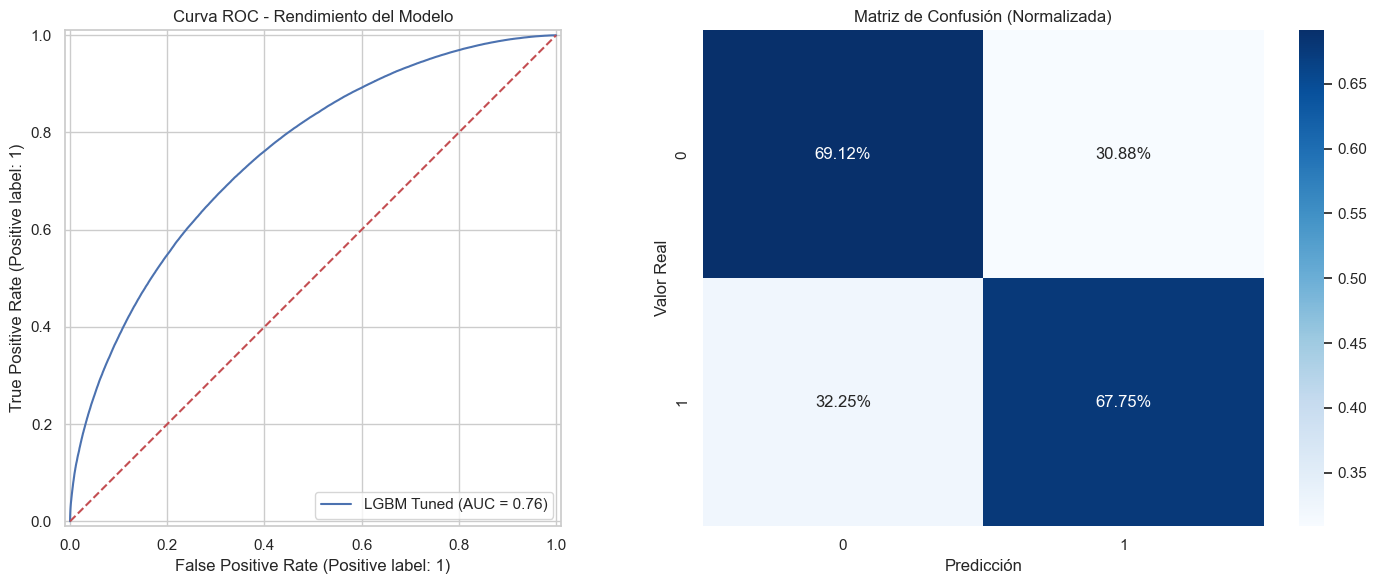

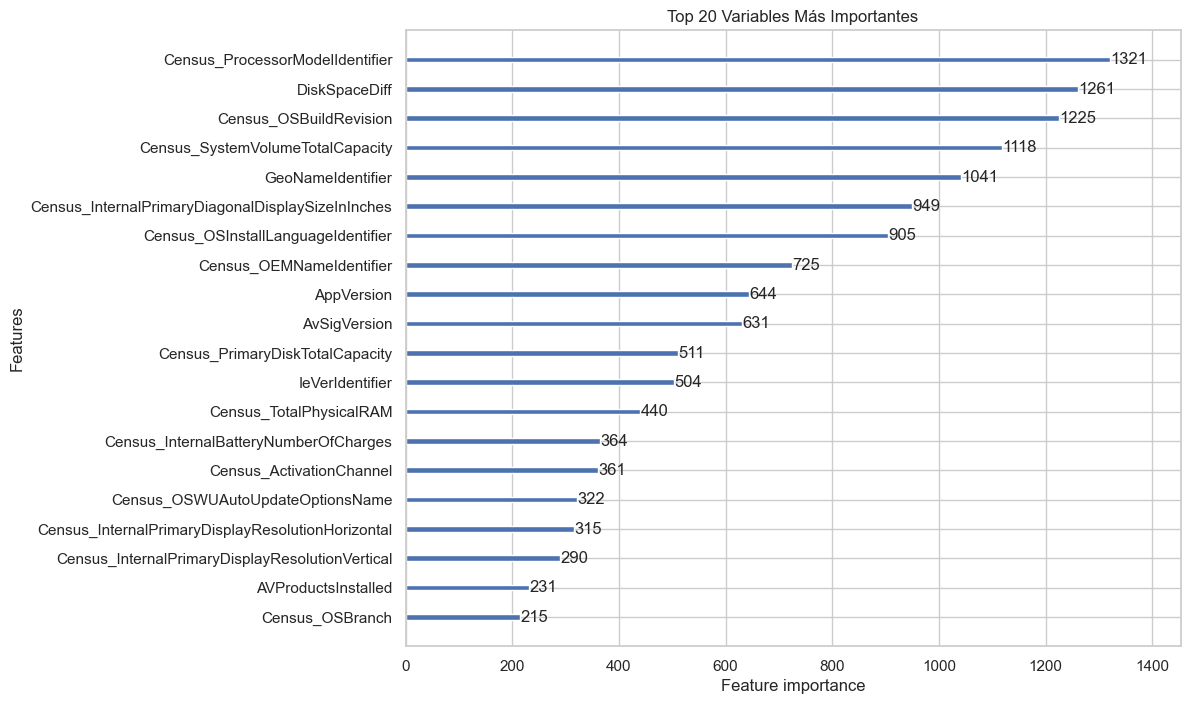

In [588]:
# Predicciones finales
# Si tienes un set de validación separado, úsalo aquí. Si no, usamos Xt (training score).
y_pred = best_model.predict(Xt)
y_proba = best_model.predict_proba(Xt)[:, 1]

# 1. Métricas Numéricas
print("=== Reporte de Clasificación ===")
print(classification_report(y, y_pred))
print(f"ROC-AUC Final: {roc_auc_score(y, y_proba):.4f}")

# 2. Visualización: Curva ROC y Matriz de Confusión
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Curva ROC
RocCurveDisplay.from_estimator(best_model, Xt, y, ax=ax[0], name='LGBM Tuned')
ax[0].set_title("Curva ROC - Rendimiento del Modelo")
ax[0].plot([0, 1], [0, 1], 'r--', label='Azar (AUC = 0.5)')
ax[0].grid(True)

# Matriz de Confusión Normalizada
#  - Tag implícito para tu referencia visual
cm = confusion_matrix(y, y_pred, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues', ax=ax[1])
ax[1].set_title("Matriz de Confusión (Normalizada)")
ax[1].set_ylabel("Valor Real")
ax[1].set_xlabel("Predicción")

plt.tight_layout()
plt.show()

# 3. Feature Importance (Vital para las conclusiones)
lgb.plot_importance(best_model, max_num_features=20, importance_type='split', figsize=(10, 8), title='Top 20 Variables Más Importantes')
plt.show()